<a href="https://colab.research.google.com/github/anderson-perez/IAC/blob/main/MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inteligência Artificial e Computacional

## Segunda Parte da Disciplina

# Informações:

- Prof. Anderson Luiz Fernandes Perez
- Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
- Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/IAC.git)

# Redes Neurais Artificiais


Uma rede neural artificial (do Inglês Artificial Neural Network) e um conjunto de unidades computacionais, chamadas de neurônio artificial, arranjadas em camadas.

Uma RNA "imita" de maneira bastante simplificada o processamento que ocorre em um neurônio biológico.

## O Neurônio Biológico

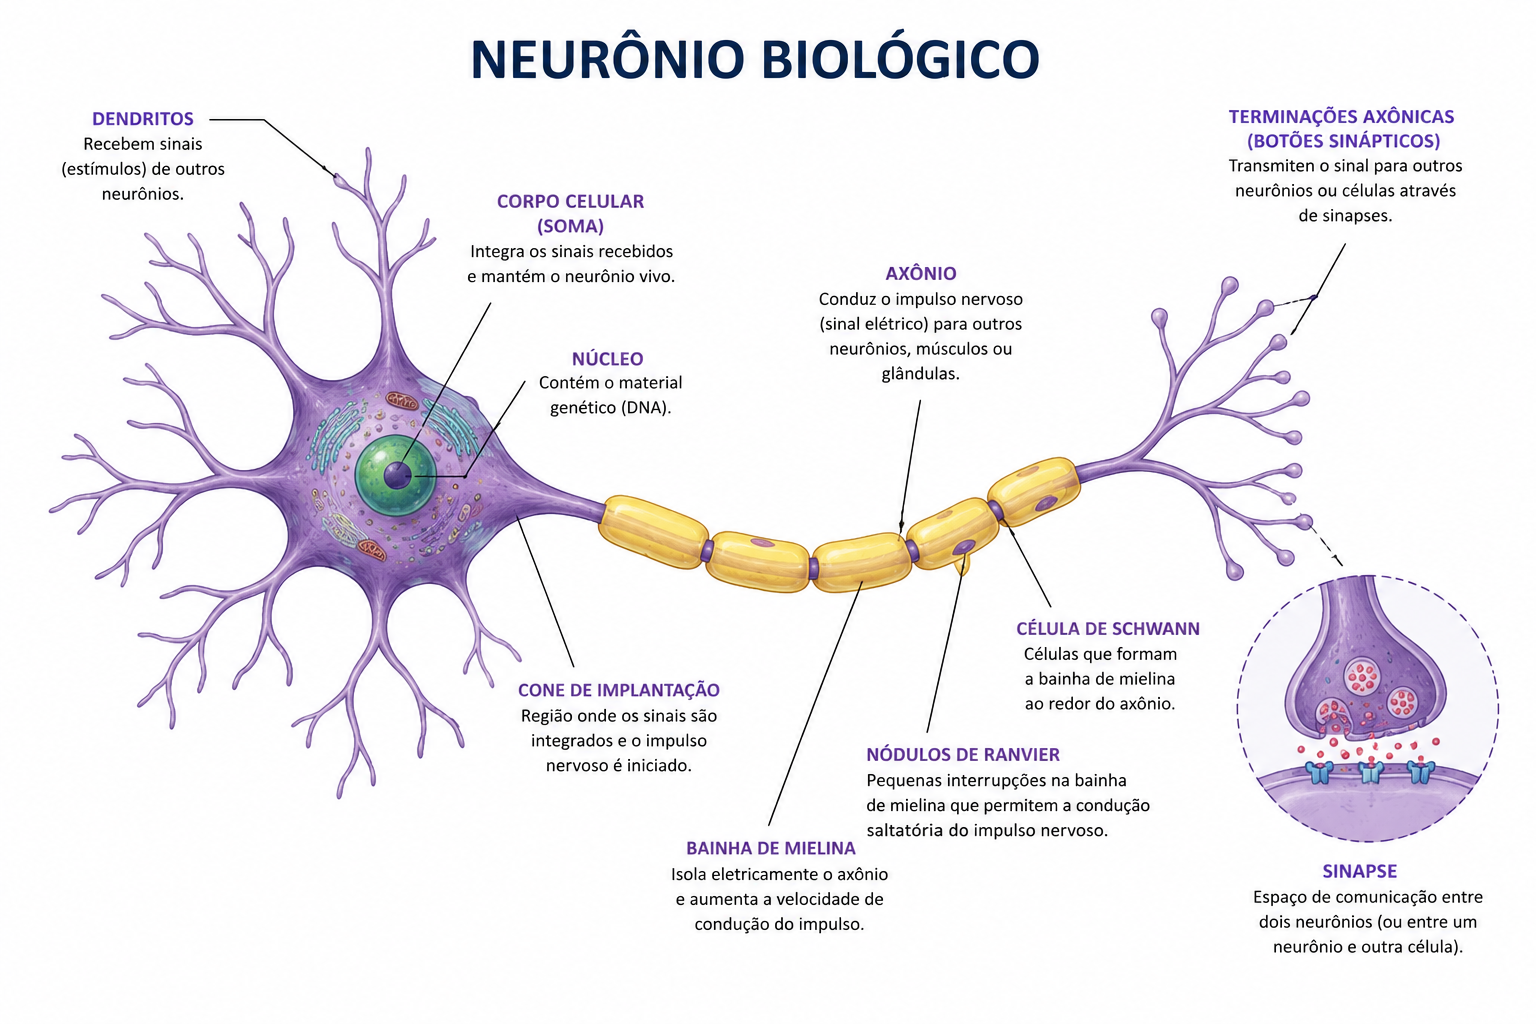

## O Perceptron



O Perceptron foi um dos primeiros modelos de RNA e foi proposto por Frank Rosenblatt em 1957.

A ideia central do Perceptron é:

* recebe estímulos de entrada.

* multiplica as entradas por pesos. Ex: $w_1, w_2, w_n$.

* calcula a soma ponderada das entradas pelos respectivos pesos sinápticos: $net = \sum w_i * x_i + b$

* aplica uma função de saída, que no caso do Perceptron é a função degrau:
$$
f(net) =
\begin{cases}
1, & \text{se } u \geq 0 \\
0, & \text{se } u < 0
\end{cases}
$$

O Perceptron era capaz de aprender automaticamente a partir de exemplos. O processo de aprendizado é basicamente o ajuste dos pesos sinápticos de acordo com os erros de **classificação**.

**Limitação:** um Perceptron não é capaz de resolver problemas não linearmente separáveis, como por exemplo, a tabela da verdade do OU EXCLUSIVO (XOR).

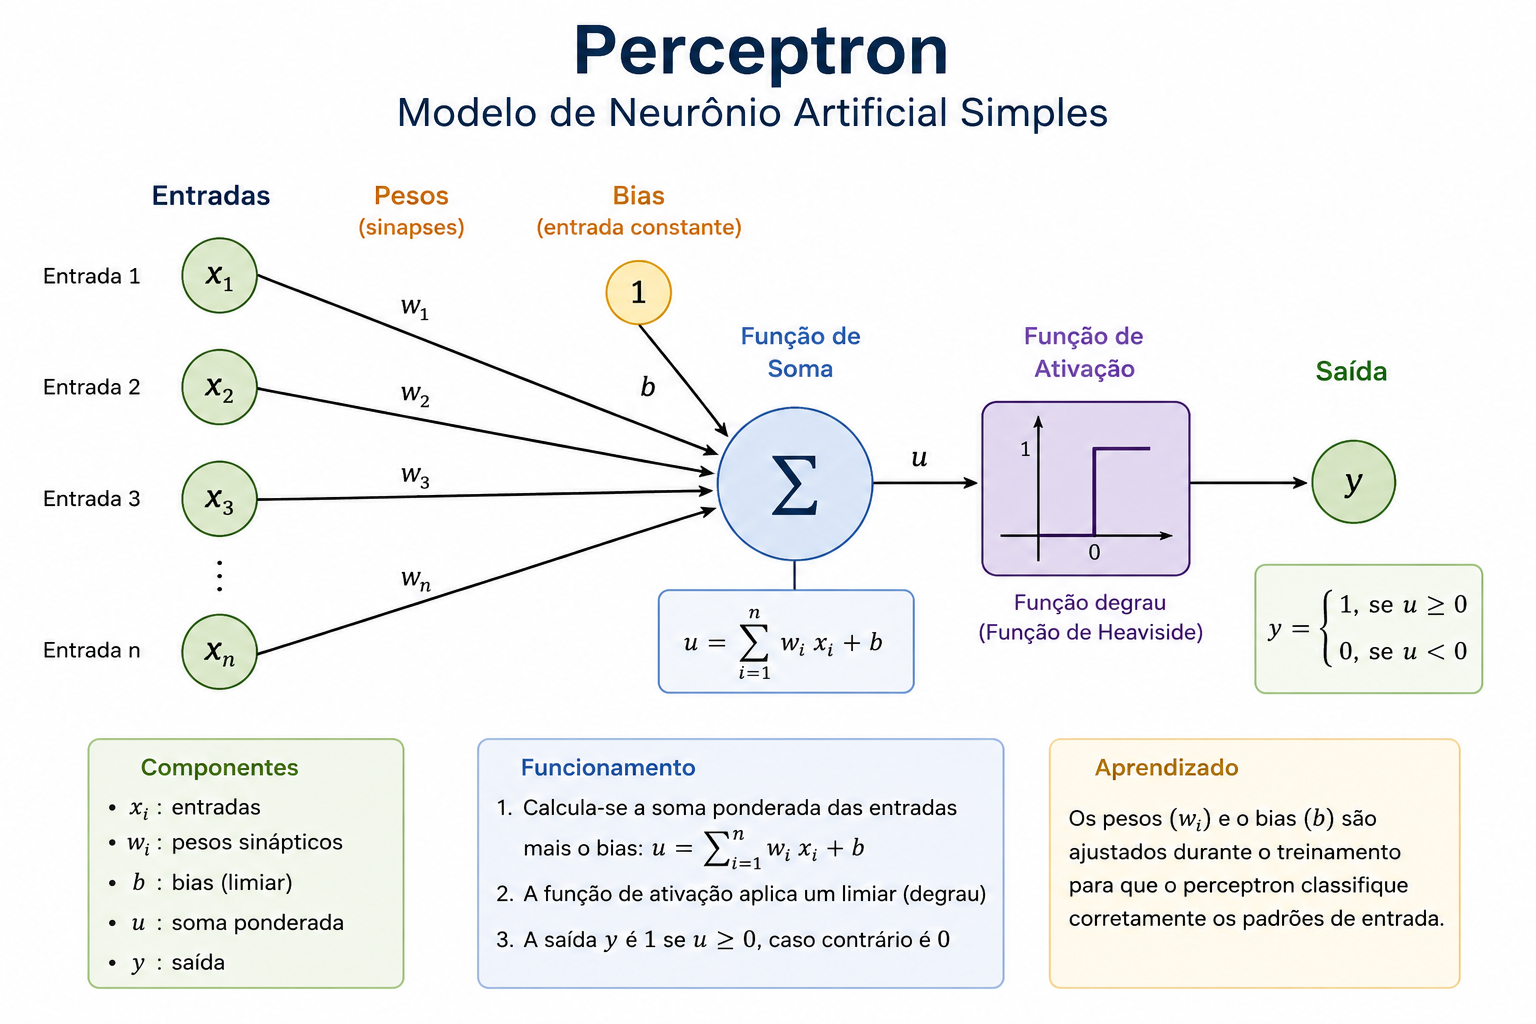

## Implementação do Perceptron em Python

In [2]:
# Entrada (tabela da verdade do AND)
X = [[0, 0], [1, 0], [0, 1], [1, 1]]
y = [0, 0, 0, 1]

# Pesos sinápticos (w[0] -> bias; w[1] -> x1; w[2] -> x2)
w = [0, 0, 0]

# Bias
b = 1

# Taxa de aprendizado
alfa = 0.07

# Vetor de erros
erros = []

# Função de ativação
def degrau(net):
  if net >= 0: return 1
  return 0

# Cálculo do erro
def calcula_erro(desejado, predito):
  return desejado - predito

# Programa o sinal adiante (feedforward)
def feedforward(x1, x2):
  net = x1 * w[1] + x2 * w[2] + b * w[0]

  return net

# Ajuste dos pesos sinápticos
def ajuste_pesos(x1, x2, erro):
  # Corrige peso bias
  w[0] = w[0] + b * erro * alfa
  # Corrige peso de x1 (w1)
  w[1] = w[1] + x1 * erro * alfa
  # Corrige peso de x2 (w2)
  w[2] = w[2] + x2 * erro * alfa

# Treinamento do Perceptron
def treinamento(epocas):
  for i in range(epocas):
    total_erros = 0
    for j in range(len(X)):
      net = feedforward(X[j][0], X[j][1])
      saida = degrau(net)
      erro = calcula_erro(y[j], saida)
      total_erros += erro
      ajuste_pesos(X[j][0], X[j][1], erro)
    erros.append(total_erros)

# Execução do Perceptron (predições)
def perceptron(x1, x2):
  return degrau(feedforward(x1, x2))

In [3]:
# Treinando o Perceptron
treinamento(10)

print(f"Pesos sinápticos..........: {w}")
print(f"Erros.....................: {erros}")

Pesos sinápticos..........: [-0.21000000000000002, 0.07, 0.14]
Erros.....................: [0, -1, -1, 0, -1, 0, 0, 0, 0, 0]


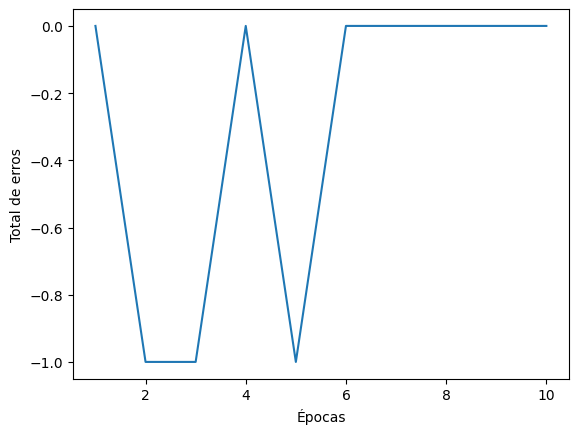

In [7]:
import matplotlib.pyplot as plt

epocas = [i for i in range(1, 11)]

plt.xlabel("Épocas")
plt.ylabel("Total de erros")
plt.plot(epocas, erros)


In [5]:
# Fazendo predições com o Perceptron
for i in range(len(X)):
  print(perceptron(X[i][0], X[i][1]))

0
0
0
1


# Perceptron de Múltiplas Camadas (Multilayer Perceptron (MLP))

Uma MLP é uma evolução do modelo Perceptron. São redes compostas por camadas de neurônios (Perceptrons) organizadas da seguinte maneira:

* camada de entrada de dados.

* $n$ camadas ocultas.

* camada de saída de dados.

Cada neurônio em uma MLP calcula $net = \sum w_i * x_i + b$ e depois aplica uma função de ativação que pode ser, por exemplo:

* ReLU

* Sigmoid

* Tangente Hiperbólica

* SoftMax



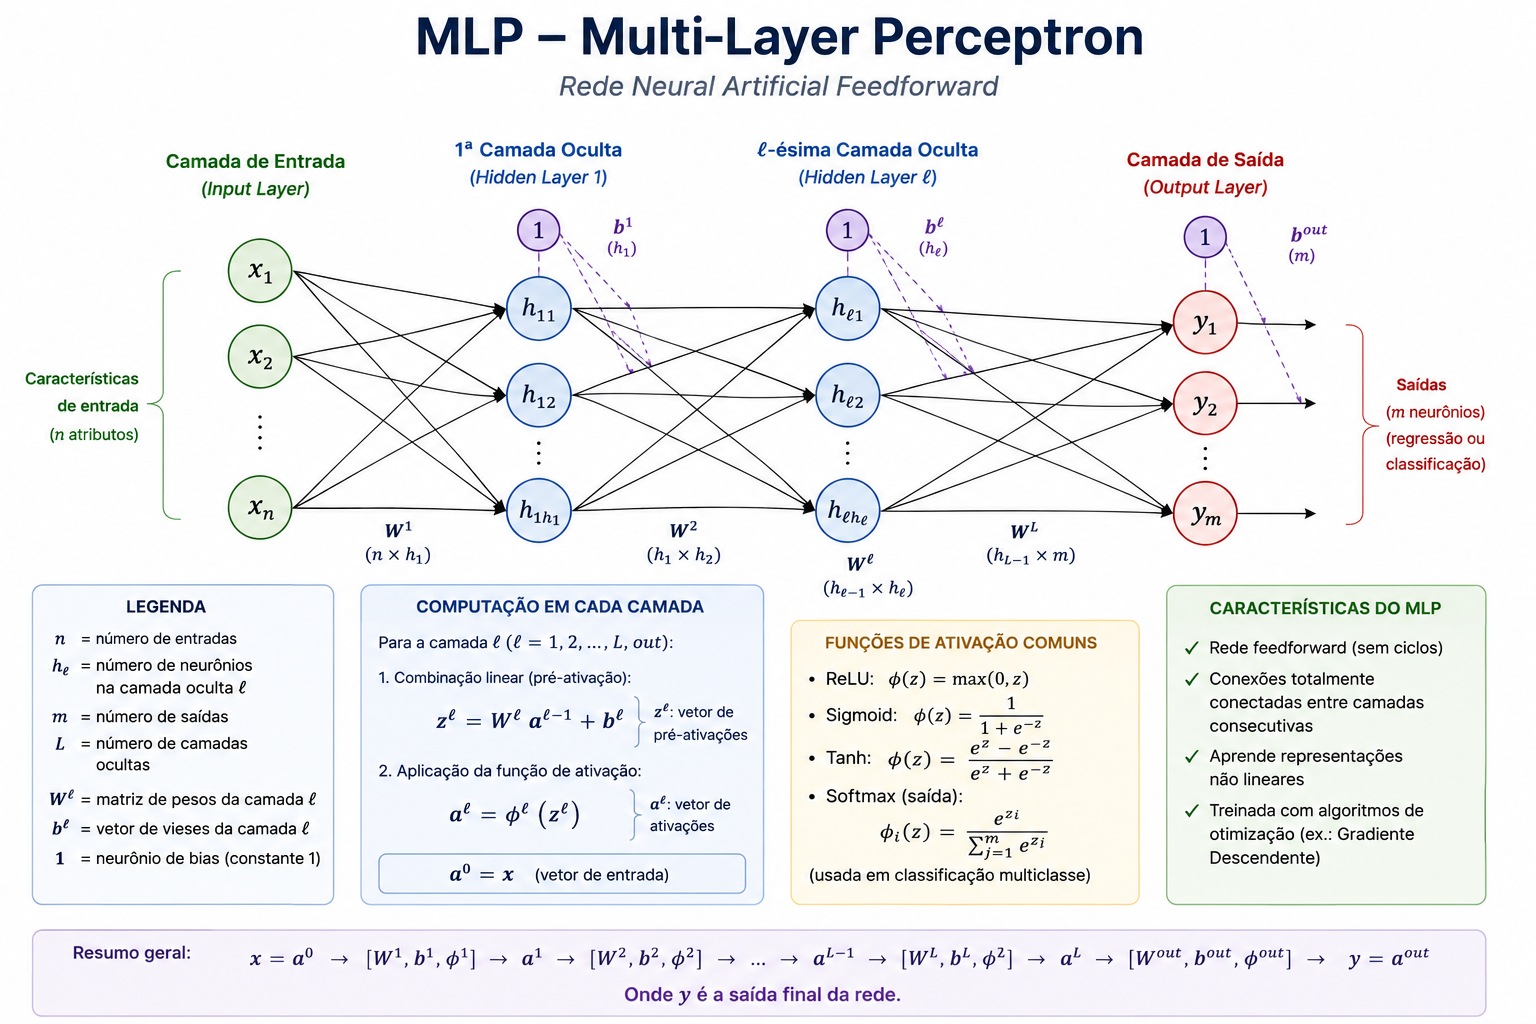

A limitação do Perceptron é a de não resolver problemas não linearmente separáveis. Uma MLP não tem este problema. Por possuir múltiplos nerônios na camada oculta consegue criar fronteiras de decisão complexas.

## Processo de Treinamento de uma MLP

O treinamento de uma rede MLP consiste em propagar os sinais de entrada em direção a saída (forward), calcular o erro, calcular os gradientes e corrigir os pesos. Este processo se repete por $i$ épocas.

### Função de Custo

A função de custo mede o erro do modelo.

- Regressão

Uma função comum é o erro quadrático médio:

$$ MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 $$

- Classificação (binária)

É comum utilizar a entropia cruzada binária:

$$ Loss = -\frac{1}{n}\sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i) \right] $$

## Algoritmo Backpropagation

A atualização dos pesos normalmente usa gradiente descendente:

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

onde:

| Símbolo | Significado |
|---|---|
| w | Peso |
| alpha | Taxa de aprendizado |
| J | Função de custo |
| $\frac{\partial J}{\partial w}$ | Gradiente |

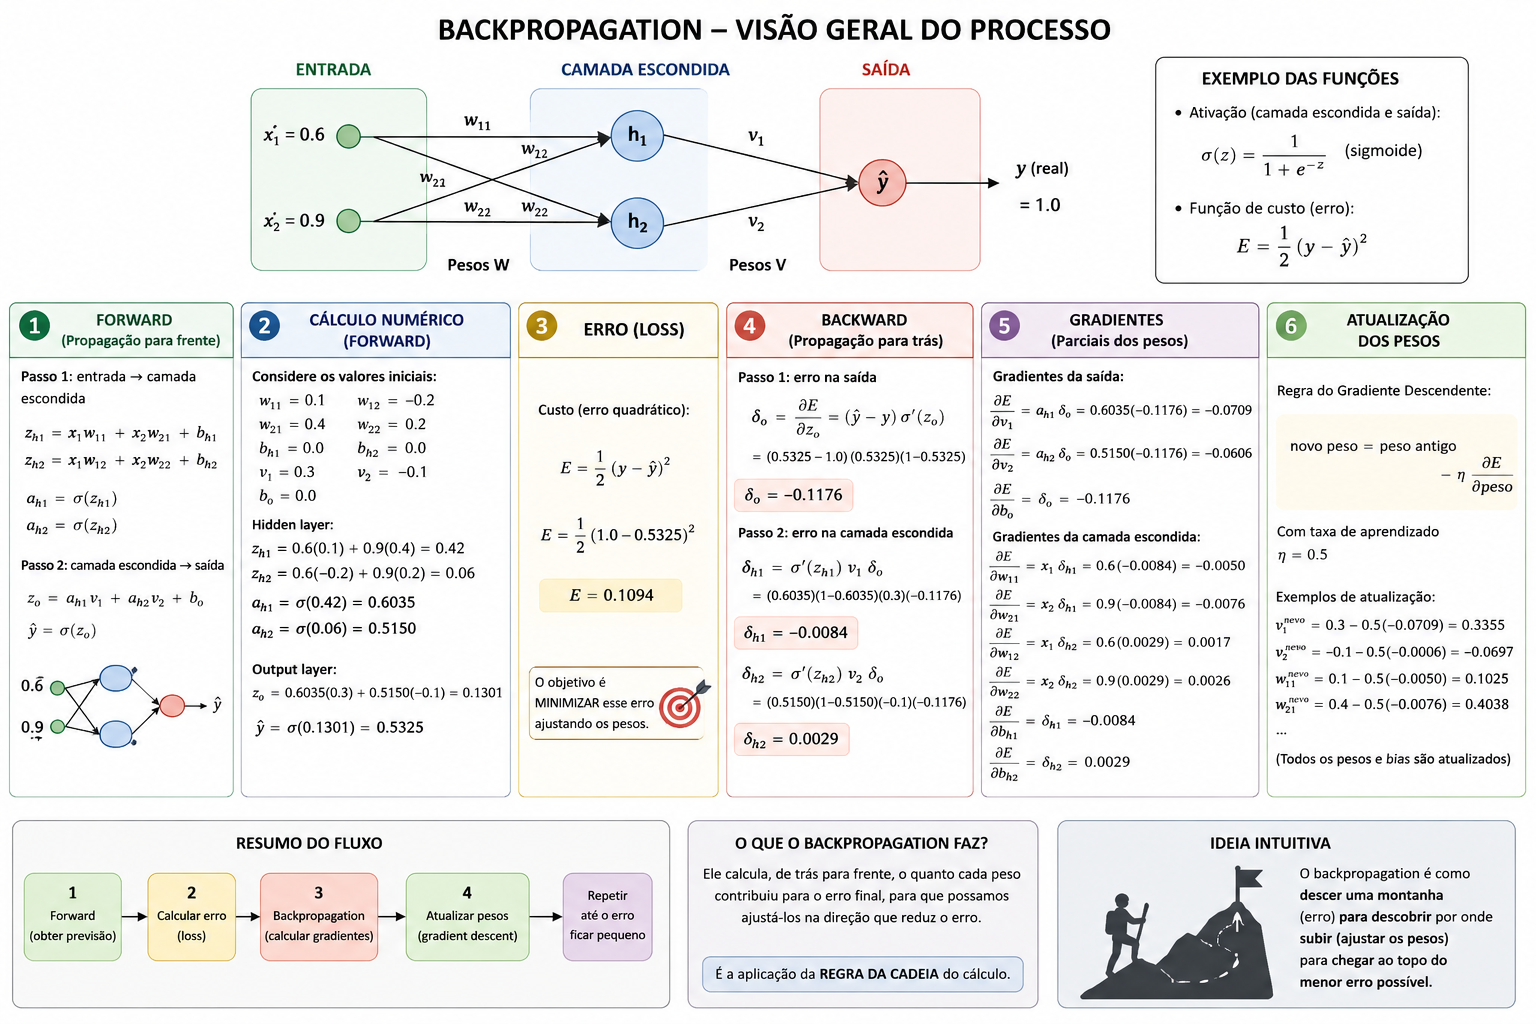

## Funções de Ativação

## Sigmoid

$ \sigma(z) = \frac{1}{1 + e^{-z}} $

A saída fica entre 0 e 1.

Muito usada em classificação binária.

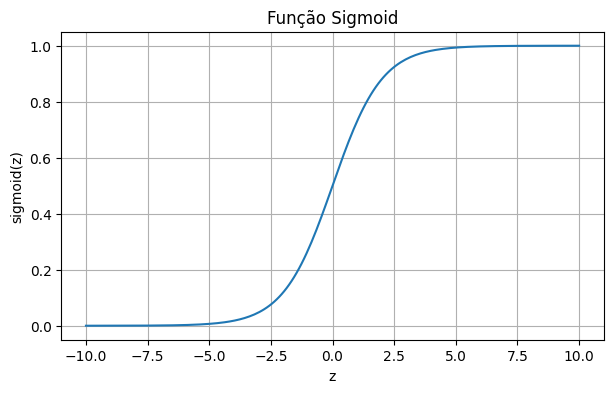

In [9]:
import matplotlib.pyplot as plt
import numpy as np

z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(7, 4))
plt.plot(z, sigmoid)
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Função Sigmoid")
plt.grid(True)
plt.show()

## ReLU

$ ReLU(z) = \max(0, z) $

A ReLU é muito usada em camadas ocultas.

Ela é simples, rápida e ajuda no treinamento de redes neurais.

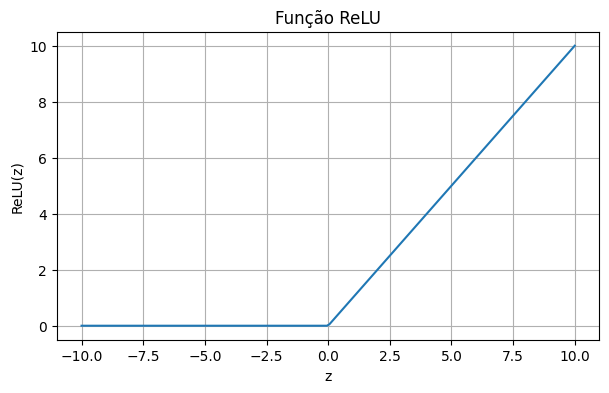

In [10]:
relu = np.maximum(0, z)

plt.figure(figsize=(7, 4))
plt.plot(z, relu)
plt.xlabel("z")
plt.ylabel("ReLU(z)")
plt.title("Função ReLU")
plt.grid(True)
plt.show()


## Tangente Hiperbólica

$ tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} $

A saída fica entre -1 e 1.

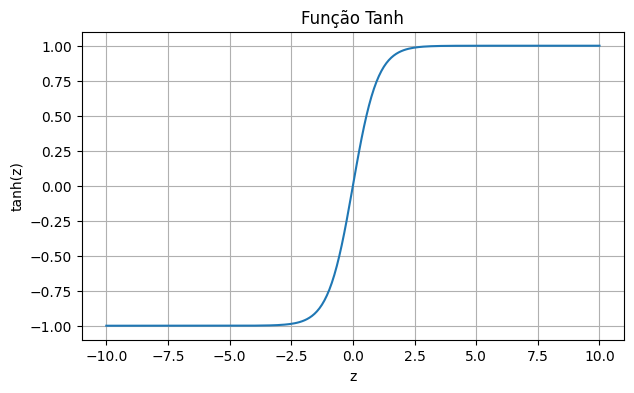

In [11]:
tanh = np.tanh(z)

plt.figure(figsize=(7, 4))
plt.plot(z, tanh)
plt.xlabel("z")
plt.ylabel("tanh(z)")
plt.title("Função Tanh")
plt.grid(True)
plt.show()


## SoftMax

Transforma um vetor de valores reais (logits) em uma distribuição de probabilidades cuja soma é igual a 1.

$$
\mathrm{Softmax}(z_i) =
\frac{e^{z_i}}
{\sum_{j=1}^{n} e^{z_j}}
$$

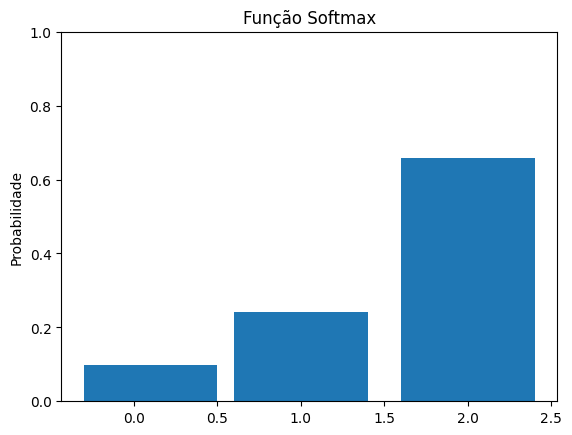

In [15]:
# Entrada
X = np.array([1.0, 2.0, 0.1])

# Normaliza os valores de x
X = X - np.max(z)

# Exponencial
exp_x = np.exp(X)

# Soma das exponenciais
soma = np.sum(exp_x)

# Softmax
soft = exp_x / soma

plt.bar(X, soft)

plt.title('Função Softmax')
plt.ylabel('Probabilidade')

plt.ylim(0, 1)

plt.show()

## Exemplo com sklearn (Classificação)

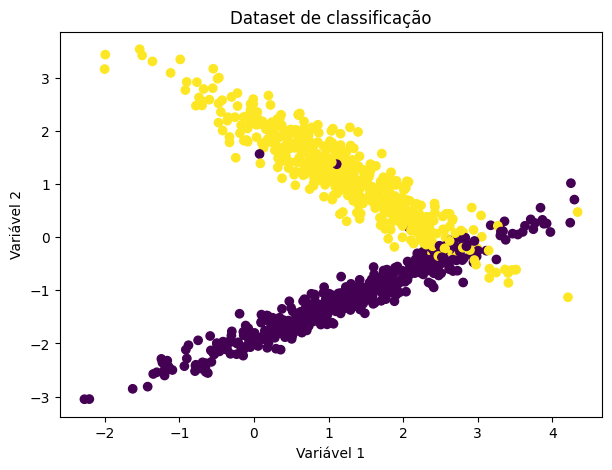

In [18]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.2,
    random_state=42
)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Variável 1")
plt.ylabel("Variável 2")
plt.title("Dataset de classificação")
plt.show()


In [19]:
# Divisão dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Normalização dos dados
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation="relu",
    solver="adam",
    learning_rate_init=0.01,
    max_iter=1000,
    random_state=42
)

mlp_clf.fit(X_train_scaled, y_train)

y_pred = mlp_clf.predict(X_test_scaled)

print(mlp_clf.score(X_test_scaled, y_test))

0.964


## Fronteira de Decisão

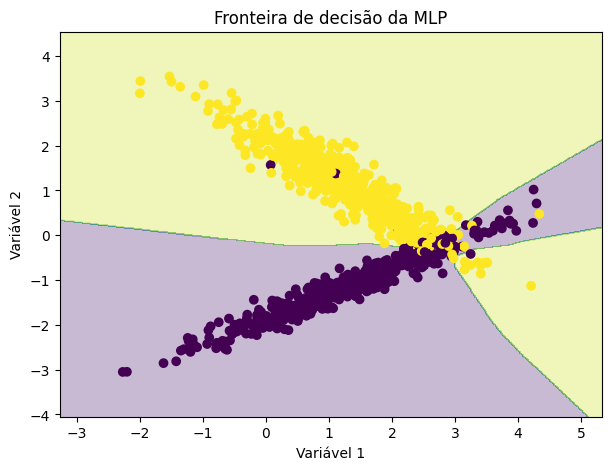

In [22]:
def plot_decision_boundary(model, scaler, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)

    Z = model.predict(grid_scaled)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.xlabel("Variável 1")
    plt.ylabel("Variável 2")
    plt.title("Fronteira de decisão da MLP")
    plt.show()

plot_decision_boundary(mlp_clf, scaler, X, y)


## Exemplo com sklearn (Regressão)

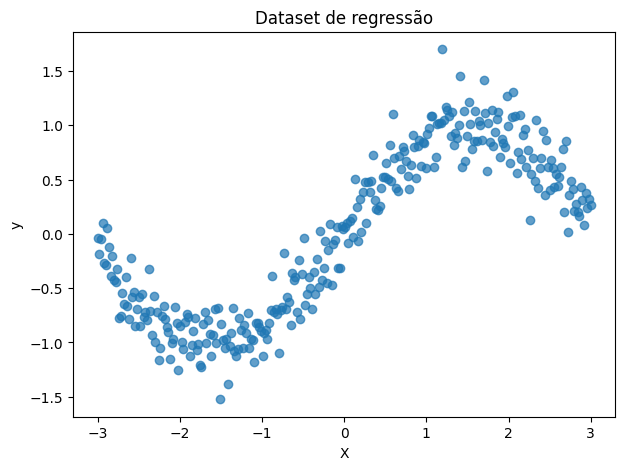

In [24]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)

X_reg = np.linspace(-3, 3, 300).reshape(-1, 1)
y_reg = np.sin(X_reg).ravel() + 0.2 * np.random.randn(300)

plt.figure(figsize=(7, 5))
plt.scatter(X_reg, y_reg, alpha=0.7)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Dataset de regressão")
plt.show()

In [25]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

mlp_reg = MLPRegressor(
    hidden_layer_sizes=(50, 50),
    activation="relu",
    solver="adam",
    learning_rate_init=0.01,
    max_iter=2000,
    random_state=42
)

mlp_reg.fit(X_train_reg_scaled, y_train_reg)

y_pred_reg = mlp_reg.predict(X_test_reg_scaled)

print("MAE :", mean_absolute_error(y_test_reg, y_pred_reg))
print("MSE :", mean_squared_error(y_test_reg, y_pred_reg))

MAE : 0.1506032349390484
MSE : 0.03489151710192801


## Fronteira de Decisão

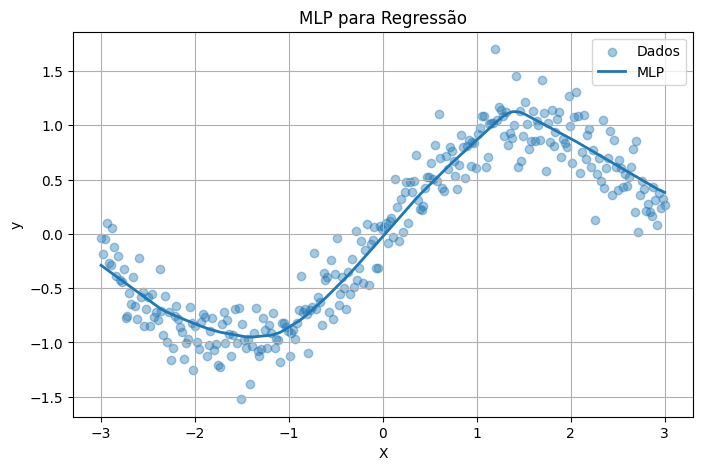

In [26]:
X_grid = np.linspace(-3, 3, 500).reshape(-1, 1)
X_grid_scaled = scaler_reg.transform(X_grid)
y_grid_pred = mlp_reg.predict(X_grid_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X_reg, y_reg, alpha=0.4, label="Dados")
plt.plot(X_grid, y_grid_pred, linewidth=2, label="MLP")
plt.xlabel("X")
plt.ylabel("y")
plt.title("MLP para Regressão")
plt.legend()
plt.grid(True)
plt.show()

# Referências

* Mãos à Obra: aprendizado de máquina com scikit-learn, keras & tensorflow.

* Inteligência Artificial - uma abordagem de aprendizado de máquina.

# Créditos

* Imagens geradas pelo chatgpt.